# Length means amount

A bar chart compares amounts across categories. The length of the bar is the amount. The baseline is zero. If the bar does not start at zero, equal-looking gaps are no longer equal amounts.

The weekly totals, sorted so the ranking is the layout:

$$
\text{Alan } 20, \quad \text{Ada } 27, \quad \text{Linus } 29, \quad \text{Grace } 34
$$

Shares of the $110$ jobs:

$$
\begin{aligned}
\text{Alan} &= 20/110 = 2/11 \\
\text{Ada} &= 27/110 \\
\text{Linus} &= 29/110 \\
\text{Grace} &= 34/110 = 17/55
\end{aligned}
$$

Use counts when the question is "how many". Use shares when the question is "what part of the week". They are different sentences, so they are different charts.


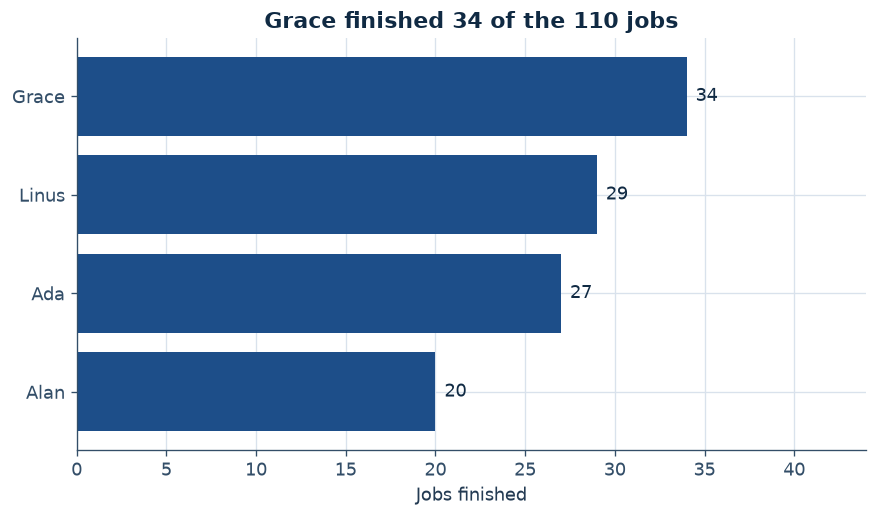

In [1]:
import matplotlib.pyplot as plt

# Quiet page: data ink first, grid behind the marks, colors that stay distinct.
plt.rcParams.update({
    "figure.figsize": (7.2, 4.2),
    "figure.dpi": 120,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "axes.axisbelow": True,
    "grid.color": "#d9e2ec",
    "axes.edgecolor": "#334e68",
    "axes.labelcolor": "#243b53",
    "xtick.color": "#334e68",
    "ytick.color": "#334e68",
    "text.color": "#102a43",
    "axes.titleweight": "bold",
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "font.size": 11,
    "savefig.facecolor": "white",
})
BLUE = "#1d4e89"
CLAY = "#c2410c"
GREEN = "#0f766e"
INK = "#102a43"
GRAY = "#9fb3c8"
plt.rcParams["axes.prop_cycle"] = plt.cycler(color=[BLUE, CLAY, GREEN])

# Counts, sorted, baseline at zero. The number is printed at the end of the bar.
from fractions import Fraction

names = ["Alan", "Ada", "Linus", "Grace"]
totals = [20, 27, 29, 34]
assert sum(totals) == 110
assert Fraction(20, 110) == Fraction(2, 11)
assert Fraction(34, 110) == Fraction(17, 55)
fig, ax = plt.subplots(constrained_layout=True)
ax.barh(names, totals, color=BLUE)
ax.set_xlabel("Jobs finished")
ax.set_xlim(0, 44)
ax.set_title("Grace finished 34 of the 110 jobs")
for row, total in enumerate(totals):
    ax.text(total + 0.5, row, str(total), va="center", color=INK)


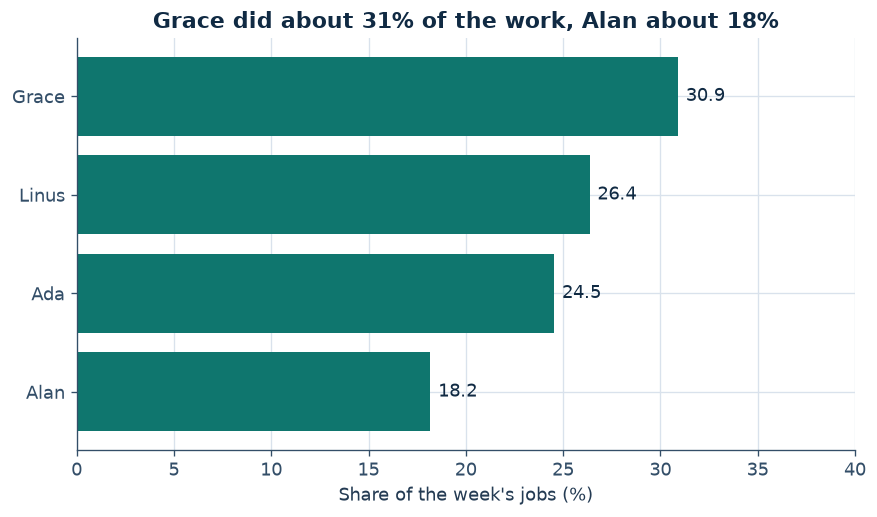

In [2]:
import matplotlib.pyplot as plt

# Quiet page: data ink first, grid behind the marks, colors that stay distinct.
plt.rcParams.update({
    "figure.figsize": (7.2, 4.2),
    "figure.dpi": 120,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "axes.axisbelow": True,
    "grid.color": "#d9e2ec",
    "axes.edgecolor": "#334e68",
    "axes.labelcolor": "#243b53",
    "xtick.color": "#334e68",
    "ytick.color": "#334e68",
    "text.color": "#102a43",
    "axes.titleweight": "bold",
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "font.size": 11,
    "savefig.facecolor": "white",
})
BLUE = "#1d4e89"
CLAY = "#c2410c"
GREEN = "#0f766e"
INK = "#102a43"
GRAY = "#9fb3c8"
plt.rcParams["axes.prop_cycle"] = plt.cycler(color=[BLUE, CLAY, GREEN])

# The same ranking, now as a share of 110. The axis is a percent, not a count.
names = ["Alan", "Ada", "Linus", "Grace"]
totals = [20, 27, 29, 34]
shares = [100 * value / 110 for value in totals]
fig, ax = plt.subplots(constrained_layout=True)
ax.barh(names, shares, color=GREEN)
ax.set_xlabel("Share of the week's jobs (%)")
ax.set_xlim(0, 40)
ax.set_title("Grace did about 31% of the work, Alan about 18%")
for row, share in enumerate(shares):
    ax.text(share + 0.4, row, f"{share:.1f}", va="center", color=INK)
assert abs(shares[-1] - (100 * 34 / 110)) < 1e-9


## Grouped bars when the day still matters

"Who led each day, Ada or Grace?" needs both the day and the person. Two bars share each day. The daily leads were already $2, 1, 2, 1, 1$. The grouped bars should show Grace taller every day, and tallest by $2$ on Monday and Wednesday.


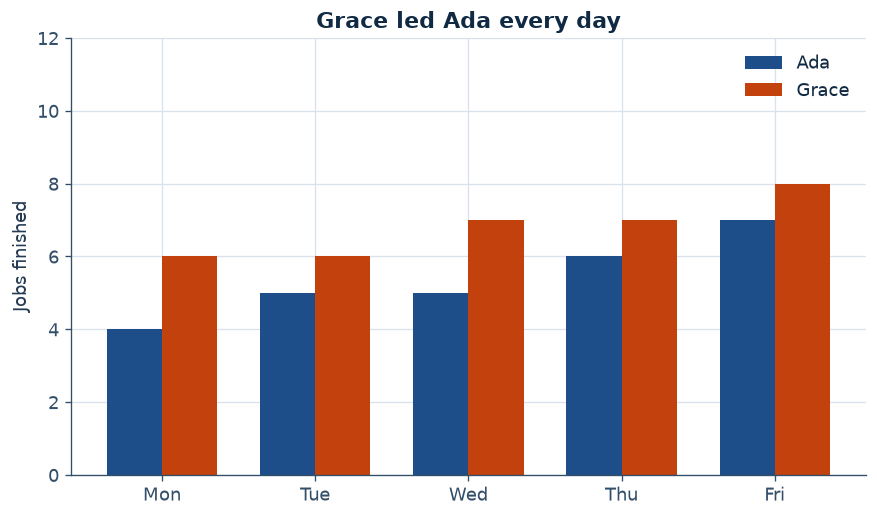

In [3]:
import matplotlib.pyplot as plt

# Quiet page: data ink first, grid behind the marks, colors that stay distinct.
plt.rcParams.update({
    "figure.figsize": (7.2, 4.2),
    "figure.dpi": 120,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "axes.axisbelow": True,
    "grid.color": "#d9e2ec",
    "axes.edgecolor": "#334e68",
    "axes.labelcolor": "#243b53",
    "xtick.color": "#334e68",
    "ytick.color": "#334e68",
    "text.color": "#102a43",
    "axes.titleweight": "bold",
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "font.size": 11,
    "savefig.facecolor": "white",
})
BLUE = "#1d4e89"
CLAY = "#c2410c"
GREEN = "#0f766e"
INK = "#102a43"
GRAY = "#9fb3c8"
plt.rcParams["axes.prop_cycle"] = plt.cycler(color=[BLUE, CLAY, GREEN])

# Two bars per day. Grace is the right-hand bar and is taller on every day.
import numpy as np

days = np.arange(5)
ada = [4, 5, 5, 6, 7]
grace = [6, 6, 7, 7, 8]
width = 0.36
fig, ax = plt.subplots(constrained_layout=True)
ax.bar(days - width / 2, ada, width, color=BLUE, label="Ada")
ax.bar(days + width / 2, grace, width, color=CLAY, label="Grace")
ax.set_xticks(days, ["Mon", "Tue", "Wed", "Thu", "Fri"])
ax.set_ylabel("Jobs finished")
ax.set_ylim(0, 12)
ax.legend(frameon=False)
ax.set_title("Grace led Ada every day")
assert all(g > a for a, g in zip(ada, grace))


## A pitfall

Start the axis at $18$ and Alan's $20$ becomes a stub, while Grace's $34$ looks several times taller. The true ratio is

$$
34/20 = 1.7
$$

Grace did $1.7$ times Alan's work, not three or four times. A bar chart that does not include zero changes the ratio the eye sees. The later lesson on scales keeps this picture next to the honest one.

## What to carry forward

Bar length is the amount, and the bar starts at zero. Sort names when you want a ranking. Use grouped bars when each group has the same small set of categories. Counts and shares answer different questions: Grace finished $34$ jobs, which is $34/110$ of the week.


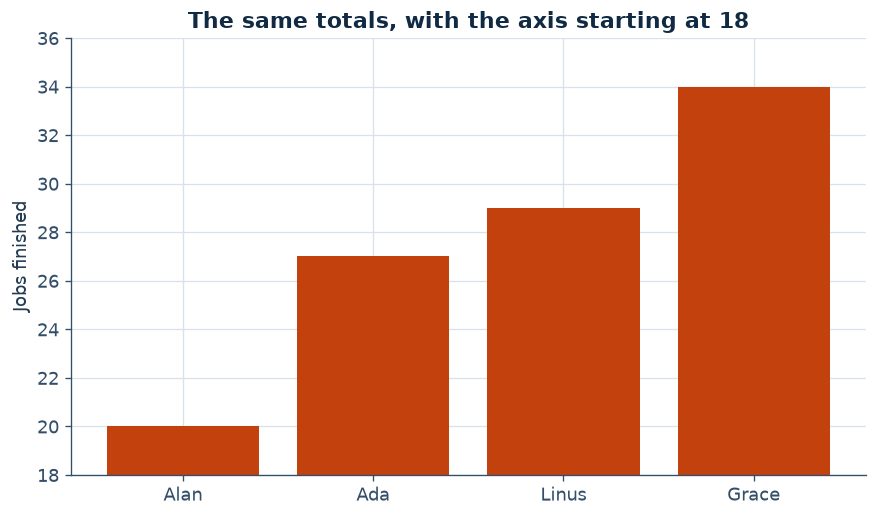

In [4]:
import matplotlib.pyplot as plt

# Quiet page: data ink first, grid behind the marks, colors that stay distinct.
plt.rcParams.update({
    "figure.figsize": (7.2, 4.2),
    "figure.dpi": 120,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "axes.axisbelow": True,
    "grid.color": "#d9e2ec",
    "axes.edgecolor": "#334e68",
    "axes.labelcolor": "#243b53",
    "xtick.color": "#334e68",
    "ytick.color": "#334e68",
    "text.color": "#102a43",
    "axes.titleweight": "bold",
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "font.size": 11,
    "savefig.facecolor": "white",
})
BLUE = "#1d4e89"
CLAY = "#c2410c"
GREEN = "#0f766e"
INK = "#102a43"
GRAY = "#9fb3c8"
plt.rcParams["axes.prop_cycle"] = plt.cycler(color=[BLUE, CLAY, GREEN])

# A cut-off axis exaggerates a 14-job gap. The honest ratio is 34/20 = 1.7.
fig, ax = plt.subplots(constrained_layout=True)
ax.bar(["Alan", "Ada", "Linus", "Grace"], [20, 27, 29, 34], color=CLAY)
ax.set_ylim(18, 36)
ax.set_ylabel("Jobs finished")
ax.set_title("The same totals, with the axis starting at 18")
assert 34 / 20 == 1.7
